# Complete Analysis on Sales Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

***Loading The Data***

In [57]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\Sales Dataset.csv")
df

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
...,...,...,...,...,...,...,...,...,...,...,...,...
1189,B-26370,8825,3594,15,Furniture,Tables,Debit Card,2024-07-31,Megan Mclean,New York,New York City,2024-07
1190,B-26298,2082,642,8,Electronics,Phones,EMI,2020-06-02,Caitlin Hunt,New York,Rochester,2020-06
1191,B-26298,2082,642,8,Electronics,Phones,EMI,2022-12-15,Jenna Holland,Texas,Austin,2022-12
1192,B-26298,2082,642,8,Electronics,Phones,EMI,2020-08-07,Stephanie Oconnell,New York,Buffalo,2020-08


***Data Understanding***

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


In [164]:
df.describe()

,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1347.374372,10.674204
std,2804.921955,1113.230122,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4472.500000,20.000000


In [9]:
df['Amount'].describe()

count    1194.000000
mean     5178.089615
std      2804.921955
min       508.000000
25%      2799.000000
50%      5152.000000
75%      7626.000000
max      9992.000000
Name: Amount, dtype: float64

In [16]:
df['Profit'].describe()

count    1194.000000
mean     1348.992462
std      1117.992573
min        50.000000
25%       410.000000
50%      1014.000000
75%      2035.000000
max      4930.000000
Name: Profit, dtype: float64

In [18]:
df['Category'].unique()

array(['Electronics', 'Office Supplies', 'Furniture'], dtype=object)

In [20]:
df['Sub-Category'].unique()

array(['Electronic Games', 'Printers', 'Pens', 'Laptops', 'Tables',
       'Chairs', 'Markers', 'Sofas', 'Paper', 'Binders', 'Phones',
       'Bookcases'], dtype=object)

In [22]:
df['Category'].value_counts()

Furniture          407
Office Supplies    399
Electronics        388
Name: Category, dtype: int64

In [24]:
df['Sub-Category'].value_counts()

Tables              122
Pens                114
Sofas               114
Markers             110
Electronic Games    104
Paper               104
Phones              101
Printers             95
Laptops              88
Bookcases            88
Chairs               83
Binders              71
Name: Sub-Category, dtype: int64

In [26]:
df['PaymentMode'].unique()

array(['UPI', 'Debit Card', 'EMI', 'Credit Card', 'COD'], dtype=object)

In [28]:
df['PaymentMode'].value_counts()

Debit Card     260
Credit Card    258
UPI            252
EMI            218
COD            206
Name: PaymentMode, dtype: int64

In [33]:
df['State'].unique()

array(['Florida', 'Illinois', 'New York', 'California', 'Texas', 'Ohio'],
      dtype=object)

In [35]:
df['City'].unique()

array(['Miami', 'Chicago', 'Buffalo', 'Orlando', 'Los Angeles',
       'New York City', 'Springfield', 'Rochester', 'Dallas', 'San Diego',
       'Austin', 'San Francisco', 'Columbus', 'Cincinnati', 'Cleveland',
       'Houston', 'Tampa', 'Peoria'], dtype=object)

In [37]:
continuous=['Amount', 'Profit']
Discrete_counts=['Quantity']
Discrete_categorical=['Order ID','Category', 'Sub-Category',
       'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City',
       'Year-Month']

In [39]:
df['Amount'].skew()         #Data is normally distributed

0.05357605459898735

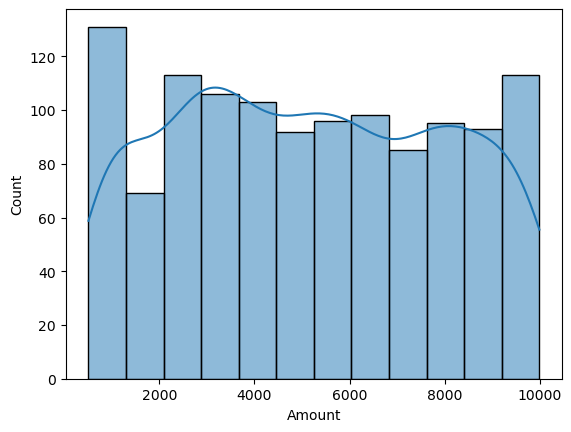

In [62]:
sns.histplot(df['Amount'],kde='True')           #Data is normally distributed
plt.show()

In [64]:
df['Profit'].skew()             #Data is normally distributed

0.943613903408805

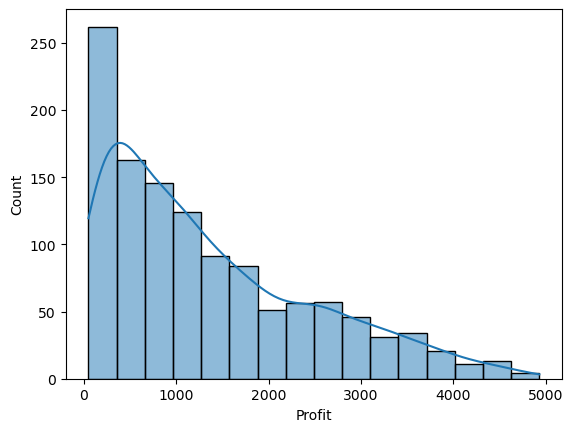

In [66]:
sns.histplot(df['Profit'],kde='True')           #Data is normally distributed
plt.show()

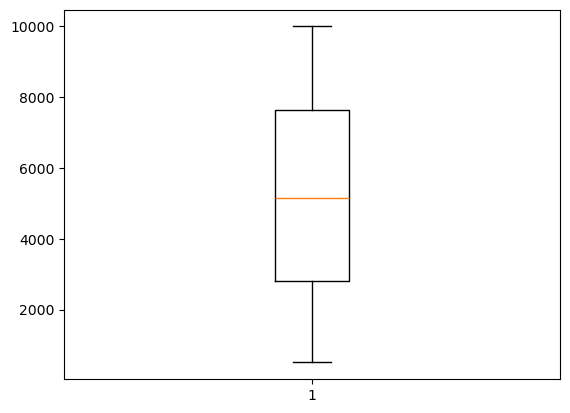

In [35]:
plt.boxplot(df['Amount'])                          #Threre is no any outliers
plt.show()

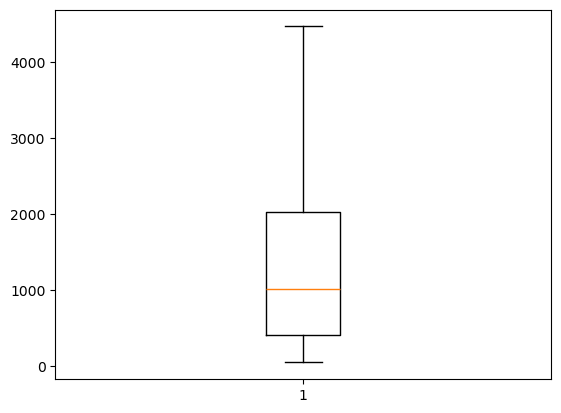

In [33]:
plt.boxplot(df['Profit'])                          #Threre is some outliers
plt.show()

***Data cleaning***

In [93]:
df.isnull().sum()            #There is no any null records 

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
CustomerName    0
State           0
City            0
Year-Month      0
dtype: int64

In [15]:
df.duplicated().sum()              #There is no any duplicate records 

0

In [80]:
df.drop(columns='CustomerName')     #Droping un important columns

,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,State,City,Year-Month
0,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,Florida,Miami,2023-06
1,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Illinois,Chicago,2024-12
2,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,New York,Buffalo,2021-07
3,4975,1330,14,Electronics,Printers,UPI,2023-06-27,Florida,Miami,2023-06
4,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Illinois,Chicago,2024-12
...,...,...,...,...,...,...,...,...,...,...
1189,8825,3594,15,Furniture,Tables,Debit Card,2024-07-31,New York,New York City,2024-07
1190,2082,642,8,Electronics,Phones,EMI,2020-06-02,New York,Rochester,2020-06
1191,2082,642,8,Electronics,Phones,EMI,2022-12-15,Texas,Austin,2022-12
1192,2082,642,8,Electronics,Phones,EMI,2020-08-07,New York,Buffalo,2020-08


In [43]:
# treat outliers
Q1=df['Profit'].quantile(0.25)
print("Q1:",Q1)
Q3=df['Profit'].quantile(0.75)
print("Q3:",Q3)
IQR = Q3-Q1
print("IQR:",IQR)

Q1: 410.0
Q3: 2035.0
IQR: 1625.0


In [53]:
upper_limit=Q3+(1.5*IQR)
print("upper_limit",upper_limit)
lower_limit=Q1-(1.5*IQR)
print("lower_limit",lower_limit)

upper_limit 4472.5
lower_limit -2027.5


In [59]:
df[(df['Profit']<lower_limit)|(df['Profit']>upper_limit)]

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
136,B-26293,9768,4518,8,Furniture,Tables,Credit Card,2021-11-26,Michael Hunt,Texas,Dallas,2021-11
189,B-25901,9883,4812,16,Office Supplies,Paper,UPI,2020-10-20,Jeffrey Middleton,New York,Buffalo,2020-10
190,B-25901,9883,4812,16,Office Supplies,Paper,UPI,2022-08-11,Veronica Kelley,Florida,Orlando,2022-08
191,B-25901,9883,4812,16,Office Supplies,Paper,UPI,2021-10-17,Leslie Bean,Illinois,Springfield,2021-10
688,B-25809,9916,4602,14,Furniture,Chairs,UPI,2022-03-08,Kelly Smith,Ohio,Cleveland,2022-03
689,B-25809,9916,4602,14,Furniture,Chairs,UPI,2022-12-08,Sabrina Hartman,Florida,Tampa,2022-12
834,B-26357,9879,4930,15,Electronics,Laptops,Debit Card,2023-06-08,Brandi Vasquez,New York,Rochester,2023-06
933,B-25646,8979,4477,4,Office Supplies,Paper,Credit Card,2020-08-24,Sharon Wilkins,Illinois,Chicago,2020-08
1061,B-25387,9775,4507,5,Office Supplies,Markers,UPI,2020-07-06,Amy Thompson,Ohio,Cincinnati,2020-07
1141,B-26565,9873,4585,7,Office Supplies,Paper,Credit Card,2020-08-10,Maria Galvan,Ohio,Columbus,2020-08


In [25]:
df['Profit']=df['Profit'].clip(lower=-2027.5,upper=4472.5)
df['Profit']

0       1275.0
1       1275.0
2       1275.0
3       1330.0
4       1330.0
         ...  
1189    3594.0
1190     642.0
1191     642.0
1192     642.0
1193     163.0
Name: Profit, Length: 1194, dtype: float64

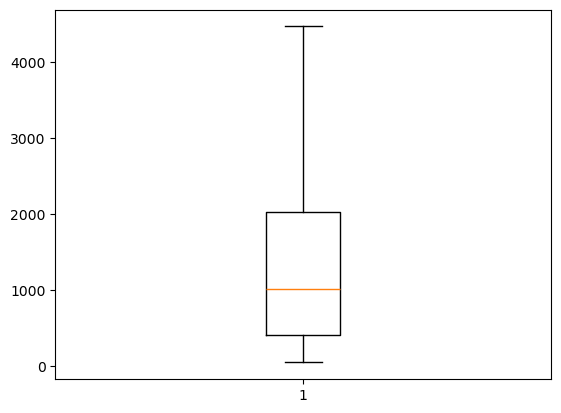

In [152]:
plt.boxplot(df['Profit'])               # Now Replaced the outliers
plt.show()

***Data Analysis***

In [7]:
df['Profit'].mean()

1348.9924623115578

In [29]:
df.groupby("Category")['Profit'].max()

Category
Electronics        4930
Furniture          4602
Office Supplies    4812
Name: Profit, dtype: int64

In [31]:
df.groupby("Category")['Profit'].min()

Category
Electronics        50
Furniture          54
Office Supplies    51
Name: Profit, dtype: int64

In [33]:
df.groupby("Category")['Profit'].mean()

Category
Electronics        1336.546392
Furniture          1328.113022
Office Supplies    1382.393484
Name: Profit, dtype: float64

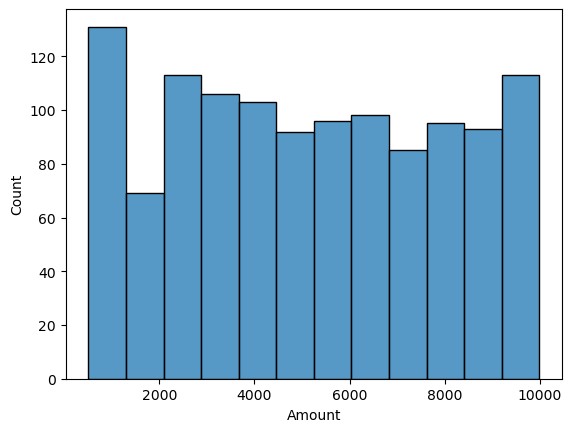

In [37]:
sns.histplot(df['Amount'])
plt.show()

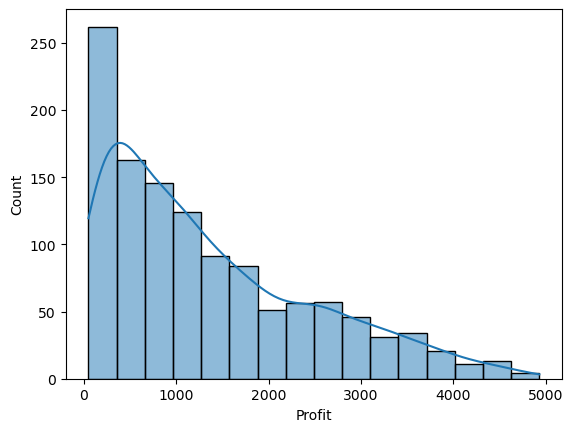

In [41]:
sns.histplot(df['Profit'],kde=True)
plt.show()

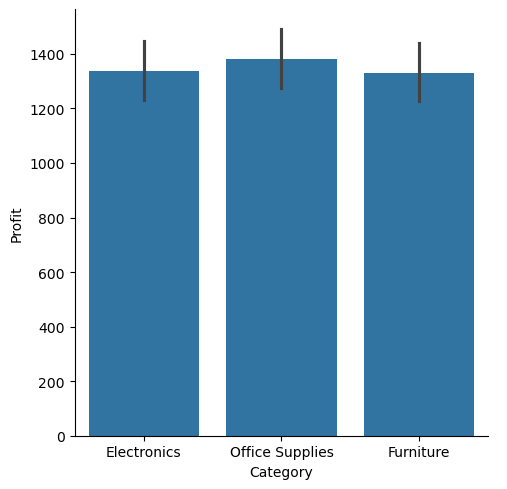

In [45]:
sns.catplot(x=df['Category'],y=df['Profit'],kind="bar")
plt.show()

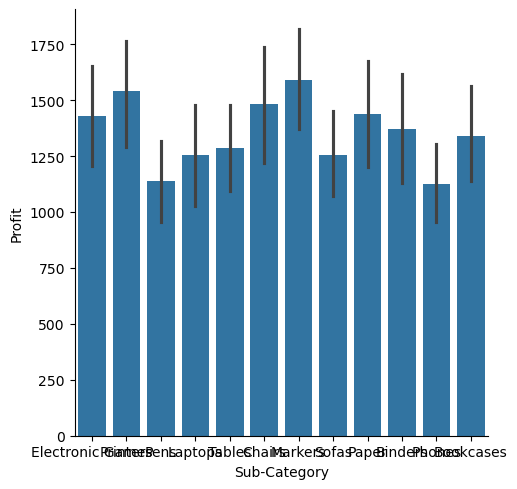

In [47]:
sns.catplot(x=df['Sub-Category'],y=df['Profit'],kind="bar")
plt.show()

In [49]:
df.groupby("Sub-Category")['Profit'].max()

Sub-Category
Binders             3895
Bookcases           4045
Chairs              4602
Electronic Games    4132
Laptops             4930
Markers             4507
Paper               4812
Pens                4401
Phones              3502
Printers            4446
Sofas               4339
Tables              4518
Name: Profit, dtype: int64

In [51]:
df.groupby("Sub-Category")['Profit'].mean()

Sub-Category
Binders             1369.816901
Bookcases           1340.909091
Chairs              1480.626506
Electronic Games    1427.442308
Laptops             1252.954545
Markers             1588.627273
Paper               1439.644231
Pens                1139.000000
Phones              1124.821782
Printers            1539.568421
Sofas               1253.105263
Tables              1285.213115
Name: Profit, dtype: float64

In [53]:
df.groupby("Sub-Category")['Profit'].min()

Sub-Category
Binders              58
Bookcases            55
Chairs               73
Electronic Games     50
Laptops              52
Markers             142
Paper                67
Pens                 51
Phones               64
Printers             60
Sofas                64
Tables               54
Name: Profit, dtype: int64

In [60]:
df.groupby('Category')['Quantity'].max()

Category
Electronics        20
Furniture          20
Office Supplies    20
Name: Quantity, dtype: int64

In [62]:
df.groupby('Category')['Quantity'].min()

Category
Electronics        1
Furniture          1
Office Supplies    1
Name: Quantity, dtype: int64

In [64]:
df.groupby('Category')['Quantity'].mean()

Category
Electronics        10.974227
Furniture          10.911548
Office Supplies    10.140351
Name: Quantity, dtype: float64

In [66]:
df.groupby('Sub-Category')['Quantity'].max()

Sub-Category
Binders             20
Bookcases           20
Chairs              19
Electronic Games    20
Laptops             20
Markers             20
Paper               20
Pens                20
Phones              20
Printers            20
Sofas               20
Tables              20
Name: Quantity, dtype: int64

In [68]:
df.groupby('Sub-Category')['Quantity'].min()

Sub-Category
Binders             1
Bookcases           1
Chairs              1
Electronic Games    1
Laptops             1
Markers             1
Paper               1
Pens                1
Phones              1
Printers            1
Sofas               1
Tables              1
Name: Quantity, dtype: int64

In [74]:
df.groupby('PaymentMode')['Amount'].mean()

PaymentMode
COD            5542.669903
Credit Card    4965.286822
Debit Card     5365.519231
EMI            5111.454128
UPI            4962.194444
Name: Amount, dtype: float64

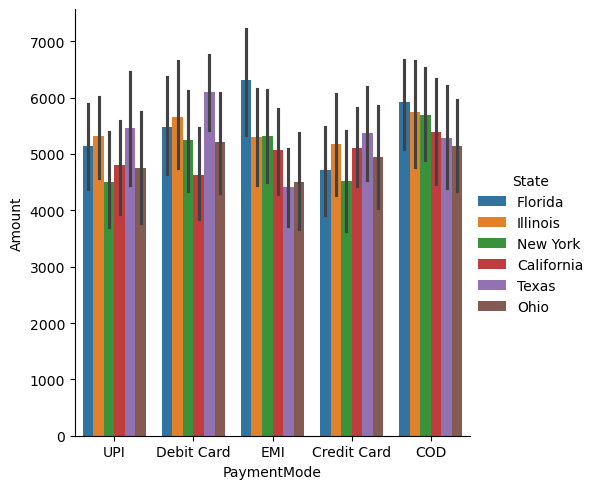

In [84]:
sns.catplot(x=df['PaymentMode'],y=df["Amount"],hue=df['State'],kind='bar')
plt.show()

In [91]:
df.groupby('PaymentMode')['Order ID'].max()

PaymentMode
COD            B-26988
Credit Card    B-26975
Debit Card     B-26993
EMI            B-26987
UPI            B-26999
Name: Order ID, dtype: object

In [93]:
df.groupby("State")["Profit"].max()

State
California    4299
Florida       4812
Illinois      4812
New York      4930
Ohio          4602
Texas         4518
Name: Profit, dtype: int64

In [95]:
df.groupby("State")["Profit"].mean()

State
California    1278.963303
Florida       1543.530000
Illinois      1328.022099
New York      1365.070796
Ohio          1202.883333
Texas         1363.915344
Name: Profit, dtype: float64

In [97]:
df.groupby("State")["Profit"].min()

State
California    54
Florida       50
Illinois      55
New York      52
Ohio          50
Texas         67
Name: Profit, dtype: int64

In [99]:
df.groupby("State")["Quantity"].max()

State
California    20
Florida       20
Illinois      20
New York      20
Ohio          20
Texas         20
Name: Quantity, dtype: int64

In [102]:
df.groupby("City")["Profit"].max()

City
Austin           3870
Buffalo          4812
Chicago          4477
Cincinnati       4507
Cleveland        4602
Columbus         4585
Dallas           4518
Houston          4339
Los Angeles      3551
Miami            4446
New York City    4441
Orlando          4812
Peoria           3968
Rochester        4930
San Diego        4299
San Francisco    4111
Springfield      4812
Tampa            4602
Name: Profit, dtype: int64

In [106]:
df.groupby("Year-Month")["Profit"].max()

Year-Month
2020-03    2444
2020-04    4446
2020-05    3374
2020-06    3033
2020-07    4507
           ... 
2024-11    2624
2024-12    2685
2025-01    4197
2025-02    3895
2025-03    3750
Name: Profit, Length: 61, dtype: int64

In [141]:
df.groupby('Year-Month')['Quantity'].mean()

Year-Month
2020-03    11.000000
2020-04     8.444444
2020-05    10.409091
2020-06    12.000000
2020-07     6.444444
             ...    
2024-11    13.615385
2024-12     7.280000
2025-01    11.062500
2025-02     8.722222
2025-03    10.400000
Name: Quantity, Length: 61, dtype: float64

In [139]:
df.groupby('Year-Month')['Quantity'].max()

Year-Month
2020-03    18
2020-04    19
2020-05    20
2020-06    20
2020-07    20
           ..
2024-11    20
2024-12    20
2025-01    20
2025-02    20
2025-03    19
Name: Quantity, Length: 61, dtype: int64

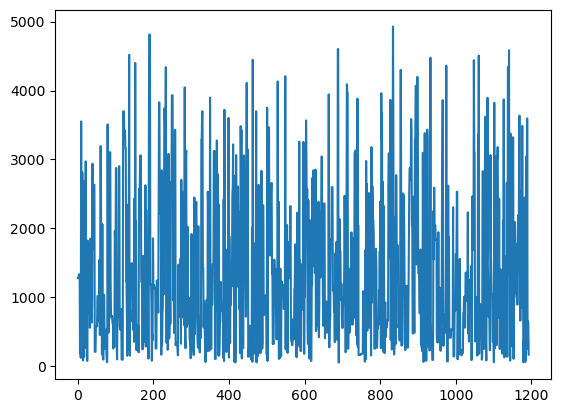

In [128]:
plt.plot(df['Profit'])
plt.show()

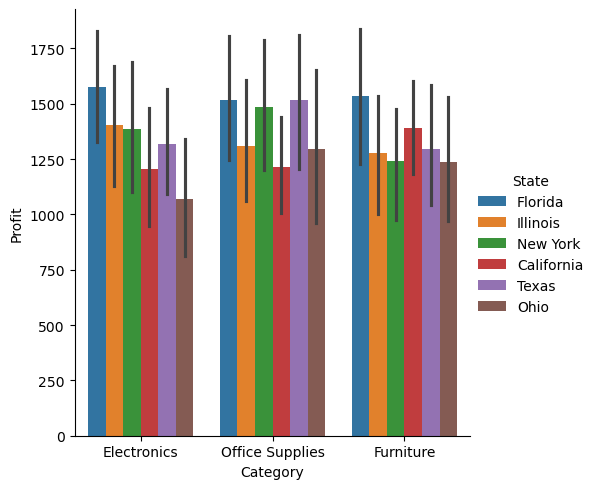

In [145]:
sns.catplot(x=df['Category'],y=df['Profit'],hue=df['State'],kind='bar')
plt.show()

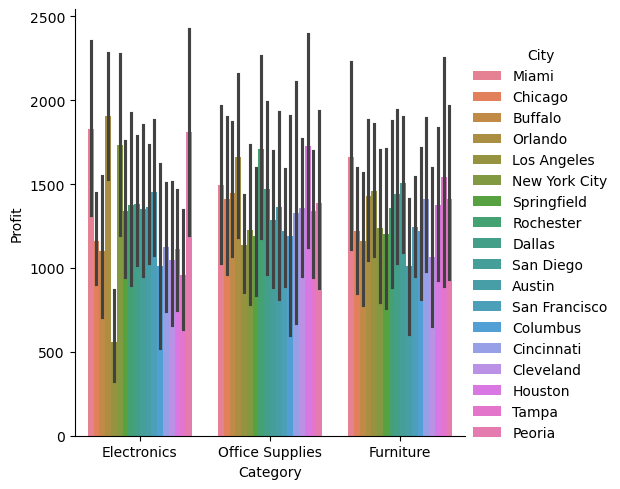

In [147]:
sns.catplot(x=df['Category'],y=df['Profit'],hue=df['City'],kind='bar')
plt.show()

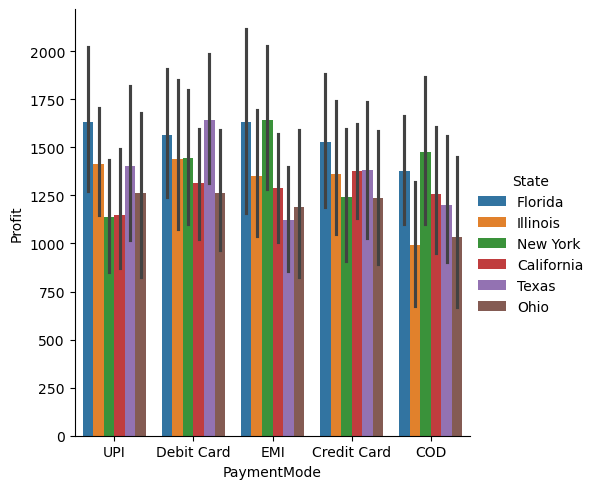

In [153]:
sns.catplot(x=df['PaymentMode'],y=df['Profit'],hue=df['State'],kind='bar')
plt.show()

In [158]:
df.groupby("State")['Quantity'].max()

State
California    20
Florida       20
Illinois      20
New York      20
Ohio          20
Texas         20
Name: Quantity, dtype: int64

In [176]:
df.groupby("Year-Month")['Profit'].mean()

Year-Month
2020-03    1548.000000
2020-04    1339.111111
2020-05    1104.272727
2020-06     948.900000
2020-07    1334.222222
              ...     
2024-11    1204.384615
2024-12     839.240000
2025-01    2412.187500
2025-02    1563.944444
2025-03    1349.700000
Name: Profit, Length: 61, dtype: float64

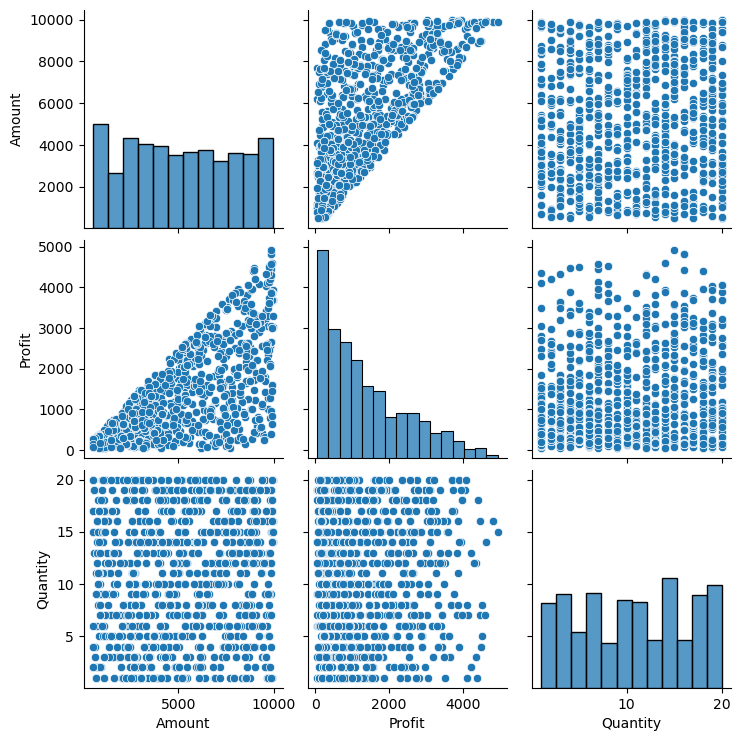

In [7]:
sns.pairplot(df)
plt.show()